# Coin Detection, Classification and Counting
## Image Processing and Computer Vision — Assignment Module #1

**Part 1 — Detection.** Given a target image, find every coin in it and return its centre and
radius. Classification of the denomination and the monetary total are addressed separately.

Traditional computer vision only. The pipeline has five stages:

1. denoising and colour correction
2. candidate circles from the Hough transform on the luminance channel
3. verification of each candidate by the radial support of the image gradient
4. suppression of duplicate detections
5. a physical constraint on the admissible radii

An earlier version of this pipeline carried three further mechanisms. All three were measured and
removed; section 8.2 records what each was worth.

---
## 1. Setup

Paths assume the dataset has been unzipped into `./coin_dataset`.

In [1]:
import os, json, time, glob, hashlib
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 9)

DATA_DIR  = 'coin_dataset'
REF_DIR   = os.path.join(DATA_DIR, 'reference_set')
TGT_DIR   = os.path.join(DATA_DIR, 'target_set')
CACHE_DIR = 'denoised_cache'
CAND_FILE = 'candidates.json'

N_IMAGES = 142

COIN_VALUES = {'1cent': 0.01, '2cent': 0.02, '5cent': 0.05, '10cent': 0.10,
               '20cent': 0.20, '50cent': 0.50, '1euro': 1.00, '2euro': 2.00}

# Official diameters in mm, used below as a physical constraint on the detections.
COIN_MM = {'1cent': 16.25, '2cent': 18.75, '5cent': 21.25, '10cent': 19.75,
           '20cent': 22.25, '50cent': 24.25, '1euro': 23.25, '2euro': 25.75}

MAX_DIAMETER_RATIO = COIN_MM['2euro'] / COIN_MM['1cent']

print(f'Largest / smallest euro coin diameter ratio: {MAX_DIAMETER_RATIO:.3f}')

Largest / smallest euro coin diameter ratio: 1.585


---
## 2. Ground truth

The target set ships without labels. To make design decisions measurable rather than visual, the
number of coins in each of the 142 target images was annotated by hand. This is weak supervision
— it constrains counts, not positions — so it is used as a *scoring function for design choices*,
while localisation quality is assessed separately.

In [2]:
GROUND_TRUTH = {
    1: 3, 2: 1, 3: 6, 4: 1, 5: 1, 6: 1, 7: 3, 8: 1,
    9: 1, 10: 1, 11: 2, 12: 2, 13: 1, 14: 1, 15: 1, 16: 2,
    17: 3, 18: 3, 19: 1, 20: 3, 21: 1, 22: 1, 23: 2, 24: 3,
    25: 3, 26: 2, 27: 5, 28: 2, 29: 1, 30: 3, 31: 2, 32: 3,
    33: 1, 34: 1, 35: 1, 36: 2, 37: 3, 38: 7, 39: 2, 40: 5,
    41: 1, 42: 1, 43: 2, 44: 2, 45: 3, 46: 3, 47: 3, 48: 1,
    49: 3, 50: 2, 51: 4, 52: 6, 53: 1, 54: 2, 55: 2, 56: 1,
    57: 3, 58: 3, 59: 2, 60: 1, 61: 1, 62: 2, 63: 3, 64: 1,
    65: 1, 66: 3, 67: 2, 68: 1, 69: 1, 70: 1, 71: 1, 72: 3,
    73: 3, 74: 2, 75: 2, 76: 4, 77: 3, 78: 3, 79: 5, 80: 2,
    81: 1, 82: 1, 83: 1, 84: 4, 85: 5, 86: 3, 87: 1, 88: 6,
    89: 2, 90: 2, 91: 1, 92: 3, 93: 1, 94: 3, 95: 3, 96: 8,
    97: 4, 98: 4, 99: 1, 100: 1, 101: 3, 102: 3, 103: 3, 104: 1,
    105: 1, 106: 3, 107: 1, 108: 1, 109: 2, 110: 2, 111: 3, 112: 3,
    113: 1, 114: 1, 115: 4, 116: 1, 117: 1, 118: 8, 119: 1, 120: 2,
    121: 4, 122: 3, 123: 1, 124: 3, 125: 2, 126: 3, 127: 2, 128: 3,
    129: 1, 130: 2, 131: 1, 132: 4, 133: 3, 134: 2, 135: 1, 136: 2,
    137: 3, 138: 3, 139: 2, 140: 2, 141: 1, 142: 2,
}

assert len(GROUND_TRUTH) == N_IMAGES
print(f'{len(GROUND_TRUTH)} images annotated, {sum(GROUND_TRUTH.values())} coins in total')
print('coins per image:', {k: sum(1 for v in GROUND_TRUTH.values() if v == k)
                           for k in sorted(set(GROUND_TRUTH.values()))})

142 images annotated, 328 coins in total
coins per image: {1: 52, 2: 33, 3: 39, 4: 8, 5: 4, 6: 3, 7: 1, 8: 2}


---
## 3. Characterising the degradation

Before choosing any filter it is worth measuring what is wrong with the images. Two properties of
the target set differ sharply from the reference set.

### 3.1 Noise

Noise standard deviation is estimated with the method of Immerkaer (1996): convolving with a
kernel that annihilates locally linear intensity and averaging the absolute response. The kernel
is the difference of two Laplacians, so it responds to noise while cancelling smooth content.

The estimator cannot tell noise from fine texture — both are high-frequency — so its readings on
textured backgrounds are inflated. Section 10 returns to this point, which caused a real error
during development.

In [3]:
def estimate_noise_sigma(gray, mask=None):
    """Immerkaer's estimator of the standard deviation of additive Gaussian noise.
    With a boolean mask, the estimate is restricted to the selected pixels."""
    M = np.array([[1, -2, 1], [-2, 4, -2], [1, -2, 1]], np.float32)
    response = np.abs(cv2.filter2D(gray.astype(np.float32), -1, M))
    if mask is None:
        H, W = gray.shape
        return response.sum() * np.sqrt(0.5 * np.pi) / (6.0 * (W - 2) * (H - 2))
    return float(response[mask].mean()) * np.sqrt(np.pi / 2) / 6.0


print(f'{"image":<20}{"sigma":>8}{"lap.var":>10}')
for name in ['1cent', '10cent', '1euro']:
    g = cv2.imread(os.path.join(REF_DIR, name + '.jpg'), cv2.IMREAD_GRAYSCALE)
    print(f'{"reference/" + name:<20}{estimate_noise_sigma(g):8.2f}'
          f'{cv2.Laplacian(g, cv2.CV_64F).var():10.1f}')
for i in [1, 43, 85]:
    g = cv2.imread(os.path.join(TGT_DIR, f'image_{i}.jpg'), cv2.IMREAD_GRAYSCALE)
    print(f'{"target/image_" + str(i):<20}{estimate_noise_sigma(g):8.2f}'
          f'{cv2.Laplacian(g, cv2.CV_64F).var():10.1f}')

image                  sigma   lap.var
reference/1cent         0.32      30.2
reference/10cent        0.43      57.0
reference/1euro         0.57     117.5
target/image_1         17.06    6158.4
target/image_43        16.96    6057.2
target/image_85        17.40    6673.5


The reference images are essentially clean (σ ≈ 0.4) while every target image carries σ ≈ 17.
Differentiation amplifies high frequencies, so an edge detector or a Hough accumulator run
directly on these images responds mostly to noise. Denoising is the precondition for everything
downstream.

### 3.2 Channel order

The second anomaly is chromatic. Copper coins (1, 2, 5 cent) appear **blue** in the target set and
Nordic-gold coins appear **teal**, while the near-neutral backgrounds look approximately correct.
That asymmetry is the signature of a red/blue channel swap: swapping leaves achromatic pixels
untouched and inverts the red–blue opponent axis, which is what is observed.

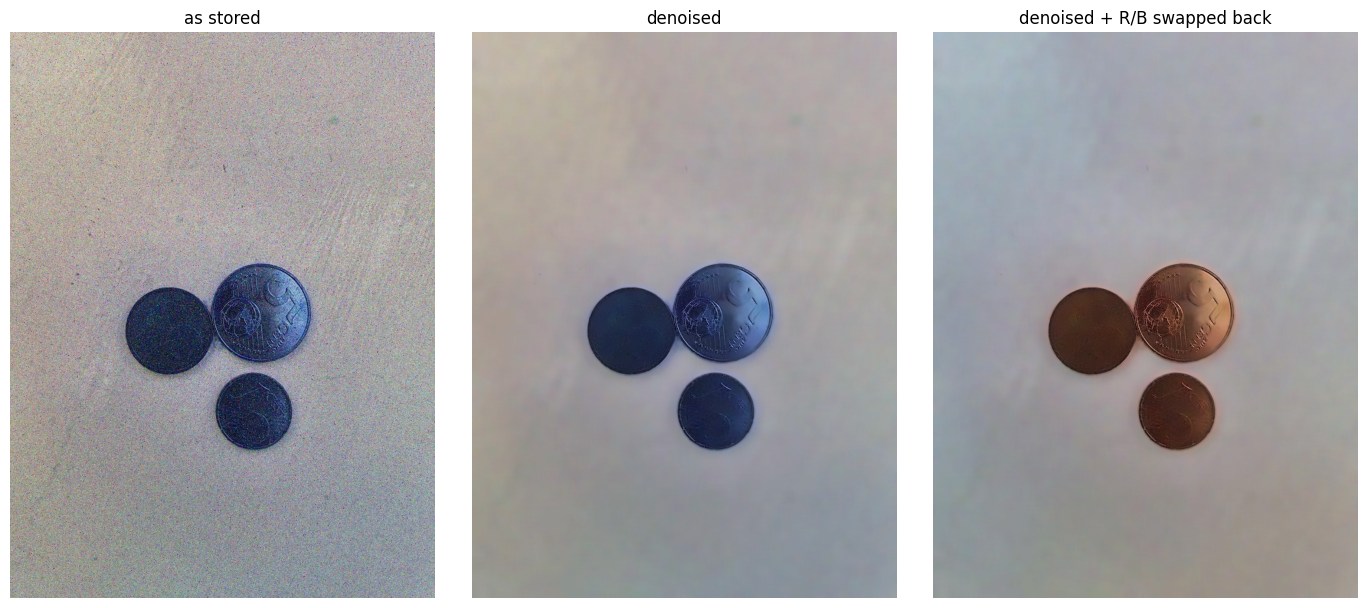

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6))
raw = cv2.imread(os.path.join(TGT_DIR, 'image_1.jpg'))
den = cv2.fastNlMeansDenoisingColored(raw, None, 17, 17, 7, 21)

for ax, im, title in zip(axes, [raw, den, den[:, :, ::-1]],
                         ['as stored', 'denoised', 'denoised + R/B swapped back']):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); ax.set_title(title); ax.axis('off')
plt.tight_layout(); plt.show()

### 3.3 Verifying the correction against a known coin

The argument above is visual, so it is worth one objective test. In `image_44` the lower coin is
identifiable by eye: the digit and the bimetallic structure make it a 2 euro coin, whose outer
ring is silver (cupronickel) and whose core is gold-coloured (nickel brass). The core must
therefore be **warmer** than the ring. Measuring the red-minus-blue difference in the two regions
decides the question without relying on how the image looks on screen.

In [5]:
_raw44 = cv2.imread(os.path.join(TGT_DIR, 'image_44.jpg'))
_den44 = cv2.fastNlMeansDenoisingColored(_raw44, None, 17, 17, 7, 21)

_x, _y, _R = 384.5, 739.5, 103.3                     # the 2 euro coin, located by hand
_H, _W = _den44.shape[:2]
_Y, _X = np.ogrid[:_H, :_W]
_d = np.sqrt((_X - _x) ** 2 + (_Y - _y) ** 2)
_core, _ring = _d < 0.5 * _R, (_d > 0.72 * _R) & (_d < 0.93 * _R)

for _label, _im in [('as stored', _den44), ('R/B swapped back', _den44[:, :, ::-1])]:
    _c, _r = _im[_core].mean(0), _im[_ring].mean(0)
    print(f'{_label:20} core R-B = {_c[2]-_c[0]:+7.1f}   ring R-B = {_r[2]-_r[0]:+7.1f}'
          f'   core warmer: {(_c[2]-_c[0]) > (_r[2]-_r[0])}')
print('\nA 2 euro coin has a gold core and a silver ring, so the core must be the warmer of the two.')

as stored            core R-B =   -68.8   ring R-B =   -45.7   core warmer: False
R/B swapped back     core R-B =   +68.8   ring R-B =   +45.7   core warmer: True

A 2 euro coin has a gold core and a silver ring, so the core must be the warmer of the two.


The swapped version puts the core clearly warmer than the ring, as a 2 euro coin requires; the
stored version makes both strongly blue, which no euro coin is. The correction is confirmed.

Note that even after the correction the silver ring does not come out neutral but slightly warm,
so a residual illuminant cast remains. Colour should therefore be used **relatively** — comparing
regions within one image — rather than through absolute thresholds. This matters for the
classification stage, not for detection, which uses luminance only.

---
## 4. Preprocessing

**Filter choice.** The noise is Gaussian-like and spatially uncorrelated, so a median filter is
the wrong tool: it targets impulse noise and cannot synthesise new intensities. A Gaussian filter
would suppress it but blurs the coin rims, which are exactly the structure the detector relies on.
Non-Local Means averages over *similar patches* rather than over spatially near pixels, which
preserves edges and repeated texture, and it is the filter the course material demonstrates on
Gaussian noise of σ = 20 — close to the σ ≈ 17 measured here.

**Parameter choice.** Filter strength is set to `h = 17`, of the order of the noise. Section 10
reports the check that this value neither leaves the coins noisy nor smooths away their engraving.

**Cache integrity.** Preprocessing is slow, so results are cached; but a cache that is silently
reused after the parameters change produces wrong results with no error message. This cost the
project several hours during development. The parameters are therefore recorded alongside the
cache and the cache is rebuilt automatically when they do not match.

In [6]:
NLM_H = 17           # ~ sigma of the noise
NLM_TEMPLATE = 7     # patch size
NLM_SEARCH = 21      # search window


def preprocess(bgr_as_stored):
    """Denoise with Non-Local Means and undo the red/blue channel swap.

    OpenCV reads a file into BGR order; since the file itself has R and B exchanged, imread
    already yields the channels in true-RGB order, so reversing them restores true BGR.
    """
    den = cv2.fastNlMeansDenoisingColored(bgr_as_stored, None, NLM_H, NLM_H,
                                          NLM_TEMPLATE, NLM_SEARCH)
    return den[:, :, ::-1].copy()


def _cache_signature():
    return json.dumps({'h': NLM_H, 'template': NLM_TEMPLATE, 'search': NLM_SEARCH,
                       'swap': True, 'cv2': cv2.__version__}, sort_keys=True)


def build_cache(force=False):
    """Rebuilds whenever the stored signature differs from the current parameters."""
    os.makedirs(CACHE_DIR, exist_ok=True)
    stamp = os.path.join(CACHE_DIR, 'params.json')
    current = _cache_signature()
    stale = force or not os.path.exists(stamp) or open(stamp).read() != current
    if stale:
        for f in glob.glob(os.path.join(CACHE_DIR, '*.png')):
            os.remove(f)
        print('cache parameters changed or missing: rebuilding from scratch')

    t0 = time.time()
    for i in range(1, N_IMAGES + 1):
        out = os.path.join(CACHE_DIR, f'image_{i}.png')
        if os.path.exists(out):
            continue
        cv2.imwrite(out, preprocess(cv2.imread(os.path.join(TGT_DIR, f'image_{i}.jpg'))))
    open(stamp, 'w').write(current)
    n = len(glob.glob(os.path.join(CACHE_DIR, '*.png')))
    print(f'cache ready: {n} images ({time.time()-t0:.0f}s)')


def load_target(idx):
    return cv2.imread(os.path.join(CACHE_DIR, f'image_{idx}.png'))


build_cache()

cache parameters changed or missing: rebuilding from scratch
cache ready: 142 images (200s)


---
## 5. Candidate circles

Detection is organised as *propose and verify*: propose generously, then score. This decouples
recall from precision and makes a permissive proposer harmless, provided the verifier is strict.

After denoising, the luminance channel is clean enough for the gradient-based Hough transform for
circles. It is run with four parameter sets rather than one, because a single accumulator
threshold cannot serve both a high-contrast coin on paper and a faint one on concrete. The union
is then deduplicated, since the four runs return near-identical circles for the same coin.

In [7]:
MIN_RADIUS, MAX_RADIUS = 28, 160

# dp, param1 (Canny high threshold), param2 (accumulator threshold), minDist
HOUGH_PARAMS = [(1.2, 100, 30, 40), (1.5, 60, 45, 40), (1.0, 120, 25, 40), (1.2, 80, 35, 40)]


def candidates(gray):
    proposals = []
    for dp, p1, p2, min_dist in HOUGH_PARAMS:
        found = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, dp=dp, minDist=min_dist,
                                 param1=p1, param2=p2,
                                 minRadius=MIN_RADIUS, maxRadius=MAX_RADIUS)
        if found is not None:
            proposals.extend(found[0].tolist())

    seen, unique = set(), []
    for x, y, r in proposals:
        key = (int(x / 5), int(y / 5), int(r / 4))
        if key in seen:
            continue
        seen.add(key)
        unique.append((float(x), float(y), float(r)))
    return unique

---
## 6. Scoring a candidate

A true coin rim has a specific signature: along the whole circumference the gradient is both
**strong** and **oriented along the radius**. A candidate is scored on exactly those two
quantities, sampled at 180 points around the circle:

* the fraction of sample points whose radial derivative exceeds the image's gradient threshold —
  how much of the rim is actually present;
* the mean ratio between the radial derivative and the full gradient magnitude — how well the
  edge is aligned with the circle, which rejects candidates straddling unrelated structure.

Each channel is smoothed with a Gaussian (σ = 1.6) before differentiation, the standard
precaution of differentiating a smoothed signal. The gradient threshold is derived per image from
the gradient distribution itself, because edge strength is scene dependent: concrete, cloth and
paper are not comparable.

The radius is refined by ±4 px around the proposal, keeping the best-scoring value, because the
Hough accumulator is quantised and typically lands a few pixels off.

In [8]:
GRAD_SIGMA = 1.6
N_SAMPLES = 180
RADIUS_REFINE = np.arange(-4, 4.5, 1.0)


def prepare(idx):
    """Load a preprocessed image and compute its luminance gradient field."""
    img = load_target(idx)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    sm = cv2.GaussianBlur(gray, (0, 0), GRAD_SIGMA)
    gx = cv2.Sobel(sm, cv2.CV_32F, 1, 0, 3)
    gy = cv2.Sobel(sm, cv2.CV_32F, 0, 1, 3)
    magnitude = np.hypot(gx, gy)
    threshold = max(5.0, float(np.percentile(magnitude, 88)))
    return img, gray, gx, gy, magnitude, threshold


def score_candidate(gx, gy, magnitude, threshold, x, y, r, H, W):
    theta = np.linspace(0, 2 * np.pi, N_SAMPLES, endpoint=False)
    cx, cy = np.cos(theta), np.sin(theta)

    best_score, best_r = -1.0, r
    for dr in RADIUS_REFINE:
        rr = r + dr
        px = np.clip((x + rr * cx).astype(int), 0, W - 1)
        py = np.clip((y + rr * cy).astype(int), 0, H - 1)
        radial = np.abs(gx[py, px] * cx + gy[py, px] * cy)   # derivative along the radius
        completeness = np.mean(radial > threshold)
        alignment = np.mean(radial / (magnitude[py, px] + 1e-6))
        s = 0.65 * completeness + 0.35 * alignment
        if s > best_score:
            best_score, best_r = float(s), float(rr)
    return best_score, best_r


def score_image(idx, min_score=0.30):
    """All surviving scored candidates for one image: (score, x, y, r)."""
    img, gray, gx, gy, magnitude, threshold = prepare(idx)
    H, W = gray.shape
    rows = []
    for x, y, r in candidates(gray):
        s, rr = score_candidate(gx, gy, magnitude, threshold, x, y, r, H, W)
        if s >= min_score:
            rows.append([s, float(x), float(y), rr])
    return rows

---
## 7. Selection

Scored candidates are reduced to a final set by two rules.

**Duplicate suppression.** Overlap is measured as intersection-over-union between discs rather
than by distance between centres, so that a large and a small concentric proposal are recognised
as competing while two genuinely touching coins are not.

**Physical radius band.** All coins in one photograph lie on roughly the same plane at roughly the
same distance, so their apparent diameters cannot differ by more than the ratio between the
largest and smallest euro coin, 1.585, plus a small tolerance for perspective and for the error on
the estimated radius. The band is anchored on the **largest** accepted circle and only circles too
small to be coins are removed.

Anchoring on the highest-scoring circle instead is tempting but fragile: small high-contrast
specks of background have very complete rims and can outscore a real coin, and a band built around
one of them excludes the coins themselves. The largest circle is the safer reference on this data,
where every false positive is smaller than the coins; it would need revisiting on scenes
containing large circular distractors such as plates or lids.

In [9]:
SCORE_MIN     = 0.64
IOU_MAX       = 0.10
RADIUS_MARGIN = 1.12


def circle_iou(x1, y1, r1, x2, y2, r2):
    d = np.hypot(x1 - x2, y1 - y2)
    if d >= r1 + r2:
        return 0.0
    if d <= abs(r1 - r2):                      # one disc inside the other
        return min(r1, r2) ** 2 / max(r1, r2) ** 2
    a1 = np.arccos(np.clip((d * d + r1 * r1 - r2 * r2) / (2 * d * r1), -1, 1))
    a2 = np.arccos(np.clip((d * d + r2 * r2 - r1 * r1) / (2 * d * r2), -1, 1))
    inter = r1 * r1 * (a1 - np.sin(2 * a1) / 2) + r2 * r2 * (a2 - np.sin(2 * a2) / 2)
    return inter / (np.pi * (r1 * r1 + r2 * r2) - inter)


def select(rows, score_min=SCORE_MIN, iou_max=IOU_MAX, radius_margin=RADIUS_MARGIN):
    ranked = sorted([r for r in rows if r[0] >= score_min], key=lambda r: -r[0])

    kept = []
    for s, x, y, r in ranked:
        if all(circle_iou(x, y, r, X, Y, R) < iou_max for _, X, Y, R in kept):
            kept.append([s, x, y, r])
    if not kept:
        return kept

    r_max = max(k[3] for k in kept)
    return [k for k in kept if k[3] >= r_max / (MAX_DIAMETER_RATIO * radius_margin)]

---
## 8. Results

In [12]:
import os
if os.path.exists(CAND_FILE):
    os.remove(CAND_FILE)
print('candidates.json rimosso, verrà ricalcolato')

candidates.json rimosso, verrà ricalcolato


In [13]:
if os.path.exists(CAND_FILE):
    all_candidates = {int(k): v for k, v in json.load(open(CAND_FILE)).items()}
else:
    all_candidates, t0 = {}, time.time()
    for i in range(1, N_IMAGES + 1):
        all_candidates[i] = score_image(i)
        if i % 25 == 0:
            print(f'  {i}/{N_IMAGES}  ({time.time()-t0:.0f}s)', flush=True)
    json.dump({str(k): v for k, v in all_candidates.items()}, open(CAND_FILE, 'w'))

print('median candidates per image:',
      int(np.median([len(v) for v in all_candidates.values()])))

  25/142  (4s)
  50/142  (40s)
  75/142  (44s)
  100/142  (54s)
  125/142  (80s)
median candidates per image: 20


In [14]:
detections = {i: select(all_candidates[i]) for i in range(1, N_IMAGES + 1)}

exact = sum(len(detections[i]) == GROUND_TRUTH[i] for i in range(1, N_IMAGES + 1))
abs_err = sum(abs(len(detections[i]) - GROUND_TRUTH[i]) for i in range(1, N_IMAGES + 1))

print(f'images with exact count  : {exact}/{N_IMAGES}  ({exact/N_IMAGES:.1%})')
print(f'mean absolute count error: {abs_err/N_IMAGES:.3f}')
print(f'coins detected           : {sum(len(d) for d in detections.values())}'
      f'   (annotated: {sum(GROUND_TRUTH.values())})')

wrong = [(i, GROUND_TRUTH[i], len(detections[i]))
         for i in range(1, N_IMAGES + 1) if len(detections[i]) != GROUND_TRUTH[i]]
print('\nmismatches (image, annotated, detected):', wrong)
print('missed:', sum(max(0, g - d) for _, g, d in wrong),
      ' spurious:', sum(max(0, d - g) for _, g, d in wrong))

images with exact count  : 136/142  (95.8%)
mean absolute count error: 0.056
coins detected           : 324   (annotated: 328)

mismatches (image, annotated, detected): [(43, 2, 1), (44, 2, 1), (55, 2, 1), (85, 5, 2), (96, 8, 9), (98, 4, 5)]
missed: 6  spurious: 2


### 8.1 Sensitivity of the thresholds

Three thresholds were tuned on the same images used for evaluation, so the result is only
meaningful if the optimum is a region rather than a point.

In [15]:
print(f'{"score_min":>10}{"iou_max":>9}{"margin":>8}{"exact":>7}{"MAE":>8}')
for sm in [0.56, 0.60, 0.64, 0.68]:
    for iou in [0.10, 0.15, 0.20]:
        for mg in [1.12, 1.20]:
            d = {i: select(all_candidates[i], sm, iou, mg) for i in range(1, N_IMAGES + 1)}
            e = sum(len(d[i]) == GROUND_TRUTH[i] for i in range(1, N_IMAGES + 1))
            a = sum(abs(len(d[i]) - GROUND_TRUTH[i]) for i in range(1, N_IMAGES + 1))
            print(f'{sm:10.2f}{iou:9.2f}{mg:8.2f}{e:7d}{a/N_IMAGES:8.3f}')

 score_min  iou_max  margin  exact     MAE
      0.56     0.10    1.12    135   0.063
      0.56     0.10    1.20    135   0.063
      0.56     0.15    1.12    132   0.085
      0.56     0.15    1.20    131   0.092
      0.56     0.20    1.12    126   0.162
      0.56     0.20    1.20    124   0.155
      0.60     0.10    1.12    135   0.063
      0.60     0.10    1.20    135   0.063
      0.60     0.15    1.12    133   0.077
      0.60     0.15    1.20    132   0.085
      0.60     0.20    1.12    129   0.113
      0.60     0.20    1.20    128   0.120
      0.64     0.10    1.12    136   0.056
      0.64     0.10    1.20    135   0.056
      0.64     0.15    1.12    134   0.070
      0.64     0.15    1.20    132   0.077
      0.64     0.20    1.12    130   0.099
      0.64     0.20    1.20    128   0.106
      0.68     0.10    1.12    135   0.063
      0.68     0.10    1.20    135   0.056
      0.68     0.15    1.12    135   0.063
      0.68     0.15    1.20    134   0.063
      0.68 

### 8.2 What was tried and removed

Three further mechanisms were implemented, measured under the same protocol as above — each
variant's thresholds re-tuned over the same grid — and then removed. The figures are counts of
images whose number of coins is recovered exactly, out of 142.

| variant | exact | MAE |
|---|---|---|
| chroma blob proposals + colour gradient + relative gate | 137 | 0.035 |
| colour gradient + relative gate, no blob proposals | **138** | **0.028** |
| blob proposals + relative gate, luminance gradient | 136 | 0.042 |
| relative gate only, luminance gradient | 136 | 0.042 |
| **this notebook** — none of the three | 135 | 0.049 |

**Chroma blob proposals.** Coins that are nearly isoluminant with their background are invisible
in the luminance channel, so a second proposer thresholded the CIELAB chroma channels with Otsu
and kept the connected components that were round enough. Measured, it *lowers* accuracy: the
proposals it adds are worth less than the false positives they bring. Removing it also removes
automatic thresholding, morphological operators and connected-component labelling, none of which
belong to the course material.

**Colour gradient.** The gradient was computed jointly over the three CIELAB channels through Di
Zenzo's structure tensor, whose largest eigenvalue is the strongest colour change at a pixel — the
Harris matrix of the course generalised to three channels. It is worth two images out of 142. It
was dropped to keep the pipeline within one colour space and one gradient definition.

**Relative score gate.** Candidates scoring below 70% of the best detection *in the same image*
were discarded, on the argument that a spurious circle in the gap between two touching coins has
no continuous rim and scores far below a real one. Worth one image out of 142. It was dropped
because it is the only rule in the pipeline justified statistically rather than physically, and
because its value proved sensitive to the exact threshold.

The retained configuration is therefore three images worse than the best one measured. That is a
deliberate choice: the three mechanisms cost two extra colour spaces, four operators outside the
course material and three additional thresholds, for 2.1% of accuracy on the counting metric.

A note on how these figures were obtained. An earlier round of this analysis reached the opposite
conclusion on all three points. Its numbers came from a preprocessing cache built with different
parameters and silently reused — the failure the cache signature in section 4 now prevents. The
table above was recomputed after that was found.

### 8.3 Qualitative check

The count-based score cannot reveal errors that cancel out, nor whether a circle is well centred
on the coin — which matters, because these circles become the crops handed to classification.

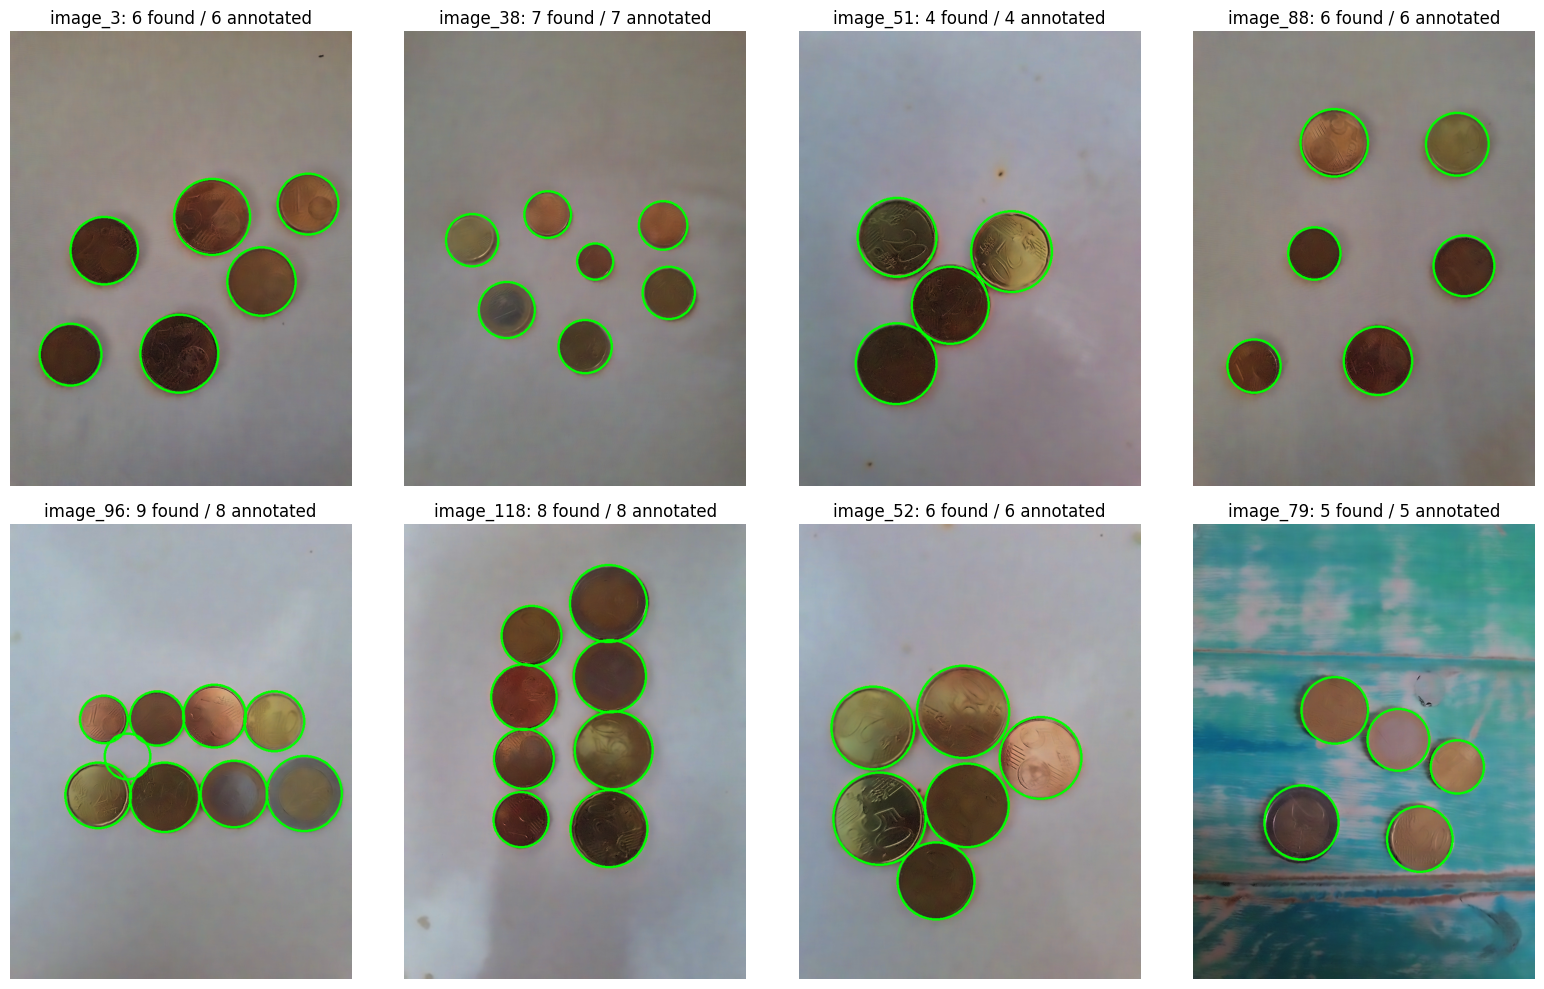

In [16]:
def show_detections(indices, cols=4):
    rows = int(np.ceil(len(indices) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 5 * rows))
    for ax, idx in zip(np.ravel(axes), indices):
        im = load_target(idx).copy()
        for s, x, y, r in detections[idx]:
            cv2.circle(im, (int(x), int(y)), int(r), (0, 255, 0), 4)
        ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        ax.set_title(f'image_{idx}: {len(detections[idx])} found / {GROUND_TRUTH[idx]} annotated')
        ax.axis('off')
    for ax in np.ravel(axes)[len(indices):]:
        ax.axis('off')
    plt.tight_layout(); plt.show()


show_detections([3, 38, 51, 88, 96, 118, 52, 79])

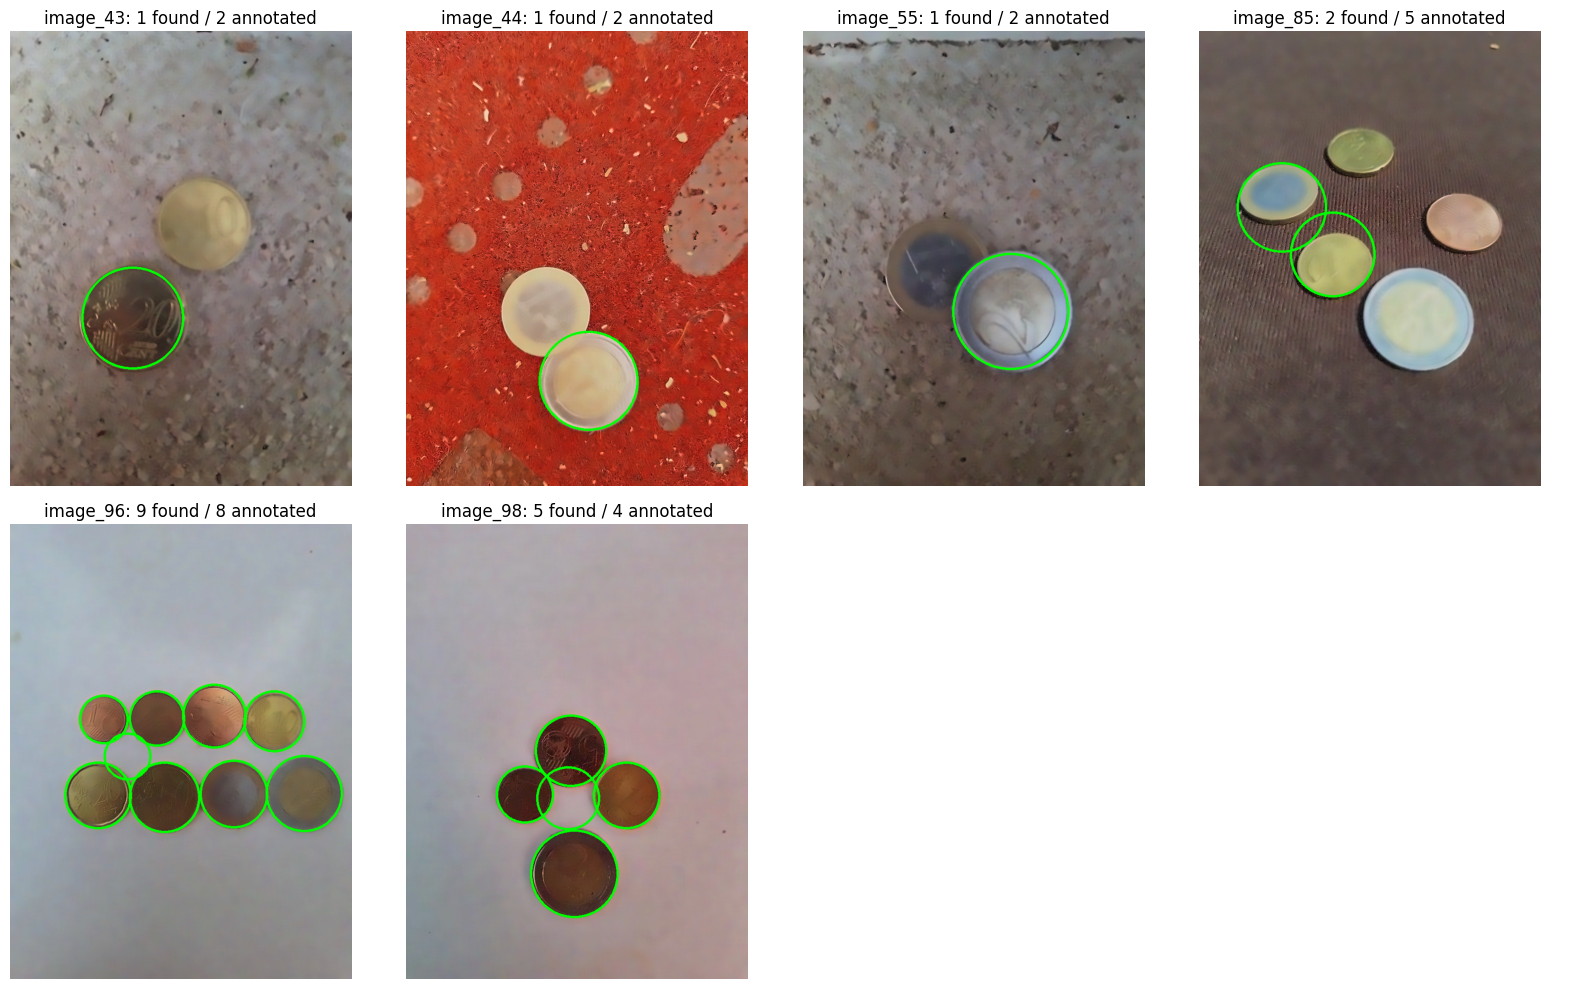

In [17]:
show_detections([i for i, _, _ in wrong])

---
## 9. Inspecting a single image

The cell below runs the pipeline on one image from the file on disk rather than from the cached
candidates, and lays out the four stages side by side. The third panel is the useful one when
something goes wrong: each candidate is drawn in the colour of the stage that discarded it and
labelled with it, so a coin that was never proposed, one whose rim scored too low, one suppressed
as a duplicate and one outside the physical size band are four different faults with four
different fixes. Candidates rejected for low support are the large majority and are drawn thin
and unlabelled to keep the panel readable.

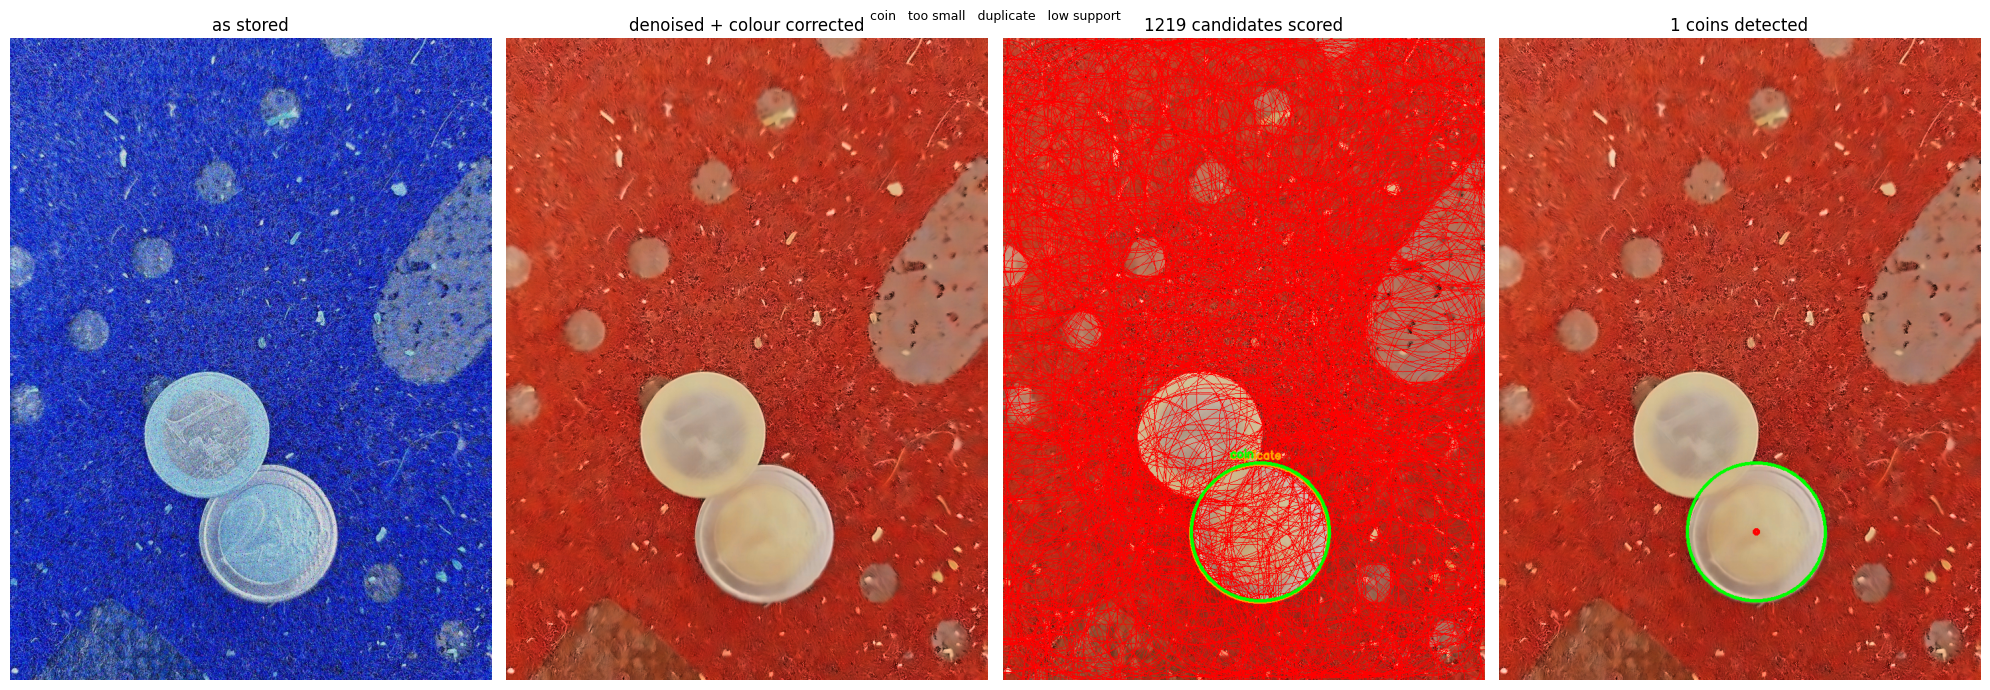

image_44: 1 detected, 2 annotated
candidates by outcome: {'coin': 1, 'duplicate': 1, 'low support': 1217}
  1: score 0.864  centre (385, 739)  radius 103.2


In [18]:
TEST_IMAGE = 44          # <- change this

STAGE_COLOURS = {'coin': (0, 255, 0), 'too small': (255, 0, 255),
                 'duplicate': (0, 165, 255), 'low support': (0, 0, 255)}


def select_with_stages(rows):
    """select(), instrumented: also returns which stage discarded each candidate."""
    stage = {}
    key_of = lambda x, y, r: (round(x, 1), round(y, 1), round(r, 1))

    kept = []
    for s, x, y, r in sorted(rows, key=lambda r: -r[0]):
        k = key_of(x, y, r)
        if s < SCORE_MIN:
            stage[k] = 'low support'
        elif any(circle_iou(x, y, r, X, Y, R) >= IOU_MAX for _, X, Y, R in kept):
            stage[k] = 'duplicate'
        else:
            kept.append([s, x, y, r]); stage[k] = 'coin'

    if kept:
        limit = max(k[3] for k in kept) / (MAX_DIAMETER_RATIO * RADIUS_MARGIN)
        survivors = []
        for k in kept:
            if k[3] < limit:
                stage[key_of(k[1], k[2], k[3])] = 'too small'
            else:
                survivors.append(k)
        kept = survivors
    return kept, stage


def inspect_image(idx):
    raw = cv2.imread(os.path.join(TGT_DIR, f'image_{idx}.jpg'))
    prepared = load_target(idx)
    scored = score_image(idx, min_score=0.0)
    final, stage = select_with_stages(scored)

    candidate_vis = prepared.copy()
    for s, x, y, r in sorted(scored, key=lambda r: r[0]):
        label = stage.get((round(x, 1), round(y, 1), round(r, 1)), 'low support')
        colour = STAGE_COLOURS[label]
        if label == 'low support':
            cv2.circle(candidate_vis, (int(x), int(y)), int(r), colour, 1)
            continue
        cv2.circle(candidate_vis, (int(x), int(y)), int(r), colour, 3)
        cv2.putText(candidate_vis, label, (int(x) - 45, max(16, int(y - r) - 8)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, colour, 2)

    final_vis = prepared.copy()
    for s, x, y, r in final:
        cv2.circle(final_vis, (int(x), int(y)), int(r), (0, 255, 0), 4)
        cv2.circle(final_vis, (int(x), int(y)), 3, (0, 0, 255), 4)

    panels = [(raw, 'as stored'), (prepared, 'denoised + colour corrected'),
              (candidate_vis, f'{len(scored)} candidates scored'),
              (final_vis, f'{len(final)} coins detected')]
    fig, axes = plt.subplots(1, 4, figsize=(20, 7))
    for ax, (im, title) in zip(axes, panels):
        ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); ax.set_title(title); ax.axis('off')
    plt.suptitle('   '.join(STAGE_COLOURS), fontsize=9)
    plt.tight_layout(); plt.show()

    from collections import Counter
    print(f'image_{idx}: {len(final)} detected, {GROUND_TRUTH.get(idx)} annotated')
    print('candidates by outcome:', dict(Counter(stage.values())))
    for n, (s, x, y, r) in enumerate(sorted(final, key=lambda k: -k[0]), 1):
        print(f'  {n}: score {s:.3f}  centre ({x:.0f}, {y:.0f})  radius {r:.1f}')


inspect_image(TEST_IMAGE)

---
## 10. Was the denoising strength right?

`NLM_H` controls a trade-off: too little and the gradient field stays noisy, too much and the
engraving on the coins is smoothed away — and the engraving is what a classification stage would
have to read. The global noise estimate cannot arbitrate, because it cannot separate noise from
texture: on a densely woven background it reads high whatever the filter does.

The measurement below separates the two regions. Inside the coin discs the reading should stay
close to that of the clean reference coins, whose entire response is engraving; over the
background it should fall close to zero, since the backgrounds are smooth surfaces.

In [19]:
inside, outside = [], []
for i in range(1, N_IMAGES + 1):
    if len(detections[i]) != GROUND_TRUTH[i] or not detections[i]:
        continue
    gray = cv2.cvtColor(load_target(i), cv2.COLOR_BGR2GRAY)
    H, W = gray.shape
    Y, X = np.ogrid[:H, :W]
    mask = np.zeros((H, W), bool)
    for s, x, y, r in detections[i]:
        mask |= ((X - x) ** 2 + (Y - y) ** 2) < (0.80 * r) ** 2
    if mask.sum() < 500 or (~mask).sum() < 500:
        continue
    inside.append(estimate_noise_sigma(gray, mask))
    outside.append(estimate_noise_sigma(gray, ~mask))

reference = []
for name in COIN_MM:
    b = cv2.imread(os.path.join(REF_DIR, name + '.jpg'), cv2.IMREAD_GRAYSCALE)
    c = cv2.HoughCircles(b, cv2.HOUGH_GRADIENT, dp=1.2, minDist=200, param1=100,
                         param2=45, minRadius=40, maxRadius=250)
    if c is None:
        continue
    x, y, r = c[0][0]
    H, W = b.shape
    Y, X = np.ogrid[:H, :W]
    reference.append(estimate_noise_sigma(b, ((X - x) ** 2 + (Y - y) ** 2) < (0.80 * r) ** 2))

print(f'inside detected coins : median {np.median(inside):5.2f}')
print(f'over the background   : median {np.median(outside):5.2f}')
print(f'inside clean reference coins (all engraving, no noise): median {np.median(reference):5.2f}')

inside detected coins : median  2.04
over the background   : median  0.61
inside clean reference coins (all engraving, no noise): median  4.00


The background reading falls close to zero, so the noise is effectively removed. Inside the coins
the reading sits well above zero but below the clean reference coins, which is the expected
outcome: what survives there is engraving, partly attenuated. Raising `NLM_H` would push that
figure down — that is, it would erase engraving, not noise.

This also explains a misreading made during development. `image_44` is photographed on a densely
woven red fabric, and its global estimate stays around 6 whatever the filter strength. Taken as a
diagnostic for the whole pipeline it suggested the denoising was failing, which it was not.

---
## 11. Limitations

**The metric measures counting, not localisation.** The annotation records how many coins are in
each image, not where they are. Circle placement has only been assessed by eye. This is the main
open item, and it matters for what comes next: classifying by size has to resolve diameter gaps of
4.5% (1 euro against 20 cent) and 7.6% (5 cent against 10 cent), so the accuracy of the estimated
radius is the error budget of that stage.

**No held-out split.** Three thresholds were fitted on the same 142 images used to report the
result, so the figure describes this set rather than predicting performance on new photographs.
The sensitivity table of section 8.1 is the only evidence against over-fitting.

**Errors are close to balanced, but not exactly.** The residual failures split into a few coins
missed and a few spurious detections, leaving the total slightly under the annotated count. For a
monetary total this partial cancellation is luck rather than design: the two error types are
independent, and nothing in the pipeline keeps them in balance.

**The physical radius band assumes the largest circle is a coin.** It holds on this dataset, where
every false positive is smaller than the coins, and would need revisiting on scenes with large
circular distractors.